<a href="https://colab.research.google.com/github/Clover130/u8229609-Individual-Project/blob/main/EMSC2010_Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Project: Groundwater Modelling in the Murray Darling Basin

## Research Question

Which climatic factor (rainfall, temperature or evapotranspiration) is the most significant predictor of groundwater level fluctuations?

Can a simple data-driven water balance model reproduce observed changes in storage and project future pumping scenarios?


## Scope

This project draws from data of a specific bore: GW030450, located in the Lower Namoi Groundwater Catchment region (Northern NSW). The bore is a shallow unconfined monitoring bore with 50 years of record (DCCEEW, 2025).

An unconfined aquifer is a permeable layer of rock, sand or gravel whose upper boundary is the water table (ie. no pearmeable layer above so water is able to rise and fall in direct contact to atmosphere). Hence this site is ideal for this project as its fluctuations will be correlated to climactic factors.

Additionally ... justify model


## Background Information

Groundwater in the Lower Namoi is under sustained pressure from agricultural extraction and climate variability. As part of the Upper Murray-Darling Basin...


The Lower Namoi alluvial aquifer supplies irrigation water to one of NSW's most productive agricultural regions. The Lower Namoi hydrogeological conceptual model report (DCCEEW, 2025) confirms groundwater levels have been declining, particularly in the Wee Waa area. It is important to understand if these changes are driven by climate or extraction.

Millenium Drought info ...

## Sources

(DCCEEW, 2025)

*Lower Namoi Hydrogeological Conceptual Model Report (Sponsored by the Murray Darling Basin Authority)*, Nov 2025, Department of Climate Change, Energy, the Environment and Water, <https://www.mdba.gov.au/sites/default/files/publications/SY%20Lower%20Namoi%20hydrogeological%20conceptual%20model%20report.pdf>.

- used for selecting bore and establishing background information

## Datasets

BOM National Groundwater Explorer (NGIS):

https://www.bom.gov.au/water/groundwater/explorer/map.shtml

SILO Climate Data:

https://longpaddock.qld.gov.au/silo/point-data/#responseTab2

The sources are all free and openly accessible. Bore GW030450 from BOM NGIS includes 50 years of water level measurements, irregularly sampled that I've resampled to monthly means with linear interpolation for missing months.
Climate data from SILO LongPaddock at the bore's coordinates includes daily rainfall, maximum temperature, FAO56 ET, and pan evaporation, aggregated to monthly totals or means.
The 50-year overlap from 1974 to 2024 captures multiple drought and wet cycles including the Millennium Drought, which provides a strong natural experiment.


**Data Categories:**
- Groundwater: Reduced Standing Water Level (RSWL, in mAHD) is the water level expressed as an elevation above the Australian Height Datum (mean sea level = 0)

- Daily rainfall (mm)
- Maximum temperature (°C)
- Pan Evaporation (mm) estimates the amount of water that could be evaporated by an open water source, essentially an indicator of atmospheric evaporative demand
- Evapotranspiration FAO56 (mm) (from the UN Food and Agriculture Organisation Irrigation) estimates reference evapotranspiration: how much water a standardised short grass surface would lose given the local climate conditions. Hence it combines temperature, humidity, wind, and solar radiation into one variable
  - international standard in hydrology and groundwater studies
  - estimates potential ET under reference conditions (actual ET may be lower under drought scenarios)


**FAIR Principles**

## Method/Analysis

- find datasets for a specific location in the Murray Darling basin

## AI Use


# Data Import

### Load Data Files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Data File Load
- requires files to be uploaded to the colab, attached in the repository

In [2]:
# Load groundwater data
gw_raw = pd.read_excel('groundwater_data_GW030170.1.1.xlsx',
                       sheet_name = 'Water Level (GW0301701.1)',
                       parse_dates=['Date'])

print("Columns:", gw_raw.columns.tolist())
print("Date dtype:", gw_raw['Date'].dtype)       # should say datetime64
print("Variables present:", gw_raw['Variable'].unique())  # should show DTW, RSWL, SWL
print(gw_raw.head(10))

# Load climate data
climate_raw = pd.read_csv('Wee_Waa_climate_data.csv', parse_dates=['YYYY-MM-DD'])
print("Columns:", climate_raw.columns.tolist())
print("Date dtype:", climate_raw['YYYY-MM-DD'].dtype)       # should say datetime64
print(climate_raw.head(10))

Columns: ['Bore ID', 'Date', 'Variable', 'Result (m)', 'Quality Code', 'Agency']
Date dtype: datetime64[ns]
Variables present: ['DTW' 'RSWL (mAHD)' 'SWL']
        Bore ID       Date     Variable  Result (m) Quality Code    Agency
0  GW030170.1.1 1972-01-24          DTW        8.33    quality-E  WaterNSW
1  GW030170.1.1 1972-01-24  RSWL (mAHD)      188.57    quality-E  WaterNSW
2  GW030170.1.1 1972-01-24          SWL        9.13    quality-E  WaterNSW
3  GW030170.1.1 1972-04-13          DTW        8.69    quality-E  WaterNSW
4  GW030170.1.1 1972-04-13  RSWL (mAHD)      188.21    quality-E  WaterNSW
5  GW030170.1.1 1972-04-13          SWL        9.49    quality-E  WaterNSW
6  GW030170.1.1 1972-05-18          DTW        8.91    quality-E  WaterNSW
7  GW030170.1.1 1972-05-18  RSWL (mAHD)      187.99    quality-E  WaterNSW
8  GW030170.1.1 1972-05-18          SWL        9.71    quality-E  WaterNSW
9  GW030170.1.1 1972-07-24          DTW        9.26    quality-E  WaterNSW
Columns: ['station',

### Clean Data Files

Clean Groundwater Data File: Extract Variables of Interest

In [3]:
## AI help here to understand resampling practise
# Groundwater dataset
# extract RSWL (absolute elevation, best for this analysis) only
rswl = gw_raw[gw_raw['Variable'] == 'RSWL (mAHD)'][['Date', 'Result (m)']].copy()
rswl = rswl.rename(columns={'Result (m)': 'RSWL_mAHD'})
rswl = rswl.set_index('Date').sort_index()

# Resample to monthly mean (due to irregular sampling and missing months in data)
# MS = Month Start frequency
gw_monthly = rswl.resample('MS').mean()

gw_monthly['RSWL_mAHD'] = gw_monthly['RSWL_mAHD'].interpolate(method='linear')

print(gw_monthly.head())

            RSWL_mAHD
Date                 
1972-01-01     188.57
1972-02-01     188.45
1972-03-01     188.33
1972-04-01     188.21
1972-05-01     187.99


Clean Climate Data File

In [4]:
# Climate dataset
# resample daily data to monthly and adjust column names
climate = climate_raw.rename(columns={
    'Date':       'YYYY-MM-DD',
    'Rain (mm)':  'daily_rain',
    'Max temp (°C)': 'max_temp',
    'et_short_crop': 'et_short_crop',
    'Pan Evaporation (mm)': 'evap_pan'
}).set_index('YYYY-MM-DD').sort_index()

# Rainfall and ET are totals hence sum each month
# Temperature is a daily max hence mean across the month
climate_monthly = climate[['daily_rain', 'et_short_crop', 'evap_pan']].resample('MS').sum()
climate_monthly['max_temp'] = climate[['max_temp']].resample('MS').mean()

Create Dataframe with all data of interest

In [5]:
# AI help
# Combine into one aligned dataframe
# Inner join only keeps the months where both datasets have data
df = gw_monthly.join(climate_monthly, how='inner')

# Flag months where groundwater was missing (NaN after resample)
n_gw_missing = gw_monthly['RSWL_mAHD'].isna().sum()
print(f"Months with no groundwater reading: {n_gw_missing}")
print(f"Final dataset: {len(df)} months from {df.index.min()} to {df.index.max()}")
print(df.head())

Months with no groundwater reading: 0
Final dataset: 629 months from 1972-01-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  daily_rain  et_short_crop  evap_pan   max_temp
Date                                                                 
1972-01-01     188.57         0.8           47.5      54.3  30.962500
1972-02-01     188.45        31.5          165.3     197.8  31.268966
1972-03-01     188.33        11.9          162.4     186.7  31.448387
1972-04-01     188.21        10.7          110.7     139.2  26.403333
1972-05-01     187.99        31.8           79.7      98.4  22.900000


#Analysis - Time Series and Frequency

Method: conduct precursory analysis to visualise and understand trends in the data.
- Time Series Analysis for each variable to compare fluctuations and plot Millenium Drought
- Frequency Analysis to seperate seasonal and long term signals in order to determine long term fluctuation
- Determine Cross Correlation between the variables to find the optimal lag to be used in later regression steps

### Visualise the Data
Plot the data including a 12 month rolling mean to visualise changes

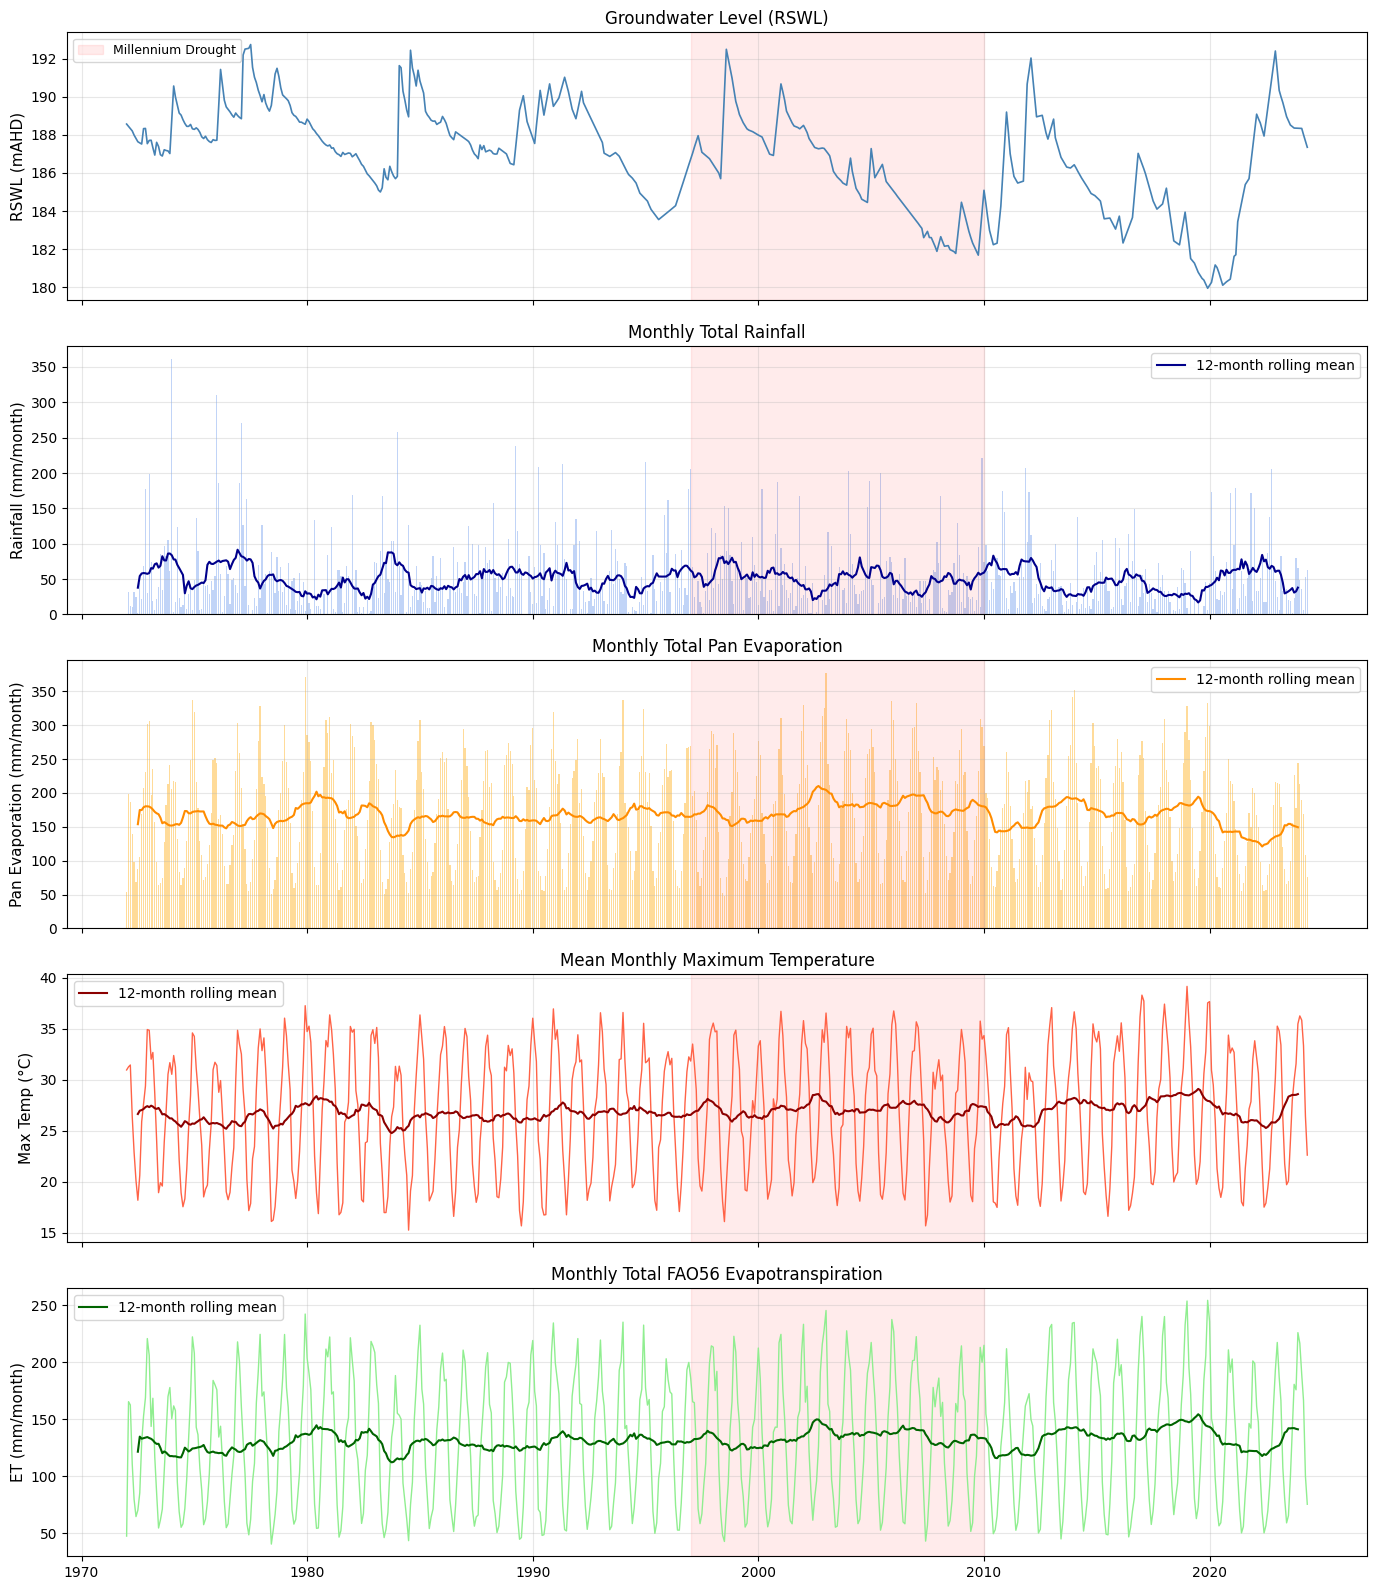

In [6]:
# Plot each variable on a timeseries axis
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Groundwater level
axes[0].plot(df.index, df['RSWL_mAHD'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('RSWL (mAHD)', fontsize=11)
axes[0].set_title('Groundwater Level (RSWL)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Rainfall
df['rainfall_12m'] = df['daily_rain'].rolling(window=12, center=True).mean() ## rolling mean
axes[1].bar(df.index, df['daily_rain'], width=20, color='cornflowerblue', alpha=0.4)
axes[1].plot(df.index, df['rainfall_12m'], color='darkblue', linewidth=1.5, label='12-month rolling mean')
axes[1].legend()
axes[1].set_ylabel('Rainfall (mm/month)', fontsize=11)
axes[1].set_title('Monthly Total Rainfall', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Pan Evaporation
df['evaporation_12m'] = df['evap_pan'].rolling(window=12, center=True).mean() ## rolling mean
axes[2].bar(df.index, df['evap_pan'], width=20, color='orange', alpha=0.4)
axes[2].plot(df.index, df['evaporation_12m'], color='darkorange', linewidth=1.5, label='12-month rolling mean')
axes[2].legend()
axes[2].set_ylabel('Pan Evaporation (mm/month)', fontsize=11)
axes[2].set_title('Monthly Total Pan Evaporation', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Max Temperature
df['max temp_12m'] = df['max_temp'].rolling(window=12, center=True).mean() ## rolling mean
axes[3].plot(df.index, df['max_temp'], color='tomato', linewidth=1.0)
axes[3].plot(df.index, df['max temp_12m'], color='darkred', linewidth=1.5, label='12-month rolling mean')
axes[3].legend()
axes[3].set_ylabel('Max Temp (°C)', fontsize=11)
axes[3].set_title('Mean Monthly Maximum Temperature', fontsize=12)
axes[3].grid(True, alpha=0.3)

# Evapotranspiration
df['evaptrans_12m'] = df['et_short_crop'].rolling(window=12, center=True).mean() ## rolling mean
axes[4].plot(df.index, df['et_short_crop'], color='lightgreen', linewidth=1.0)
axes[4].plot(df.index, df['evaptrans_12m'], color='darkgreen', linewidth=1.5, label='12-month rolling mean')
axes[4].legend()
axes[4].set_ylabel('ET (mm/month)', fontsize=11)
axes[4].set_title('Monthly Total FAO56 Evapotranspiration', fontsize=12)
axes[4].grid(True, alpha=0.3)
#axes[4].xaxis.set_major_locator(years)
#axes[4].xaxis.set_major_formatter(years_fmt)

# Shade the Millennium Drought period for reference across all panels (AI help)
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()



Distinct correlations are hard to determine from this plot, however a general increase in temperature and decrease in rainfall is evident across the Millenium Drought period. This appears to correlate to the decline in groundwater levels however further analysis is required to quantify this correlation.

### Seasonal Decomposition
Isolate the signal to compare seasonal cycles and multi-year variability

#### Frequency Functions (modified code from course content)

In [7]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

#### Groundwater Frequency Analysis

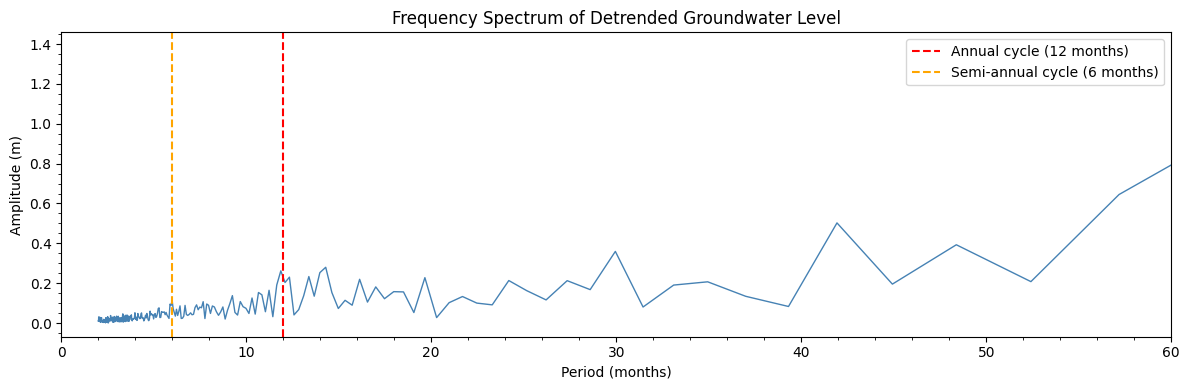

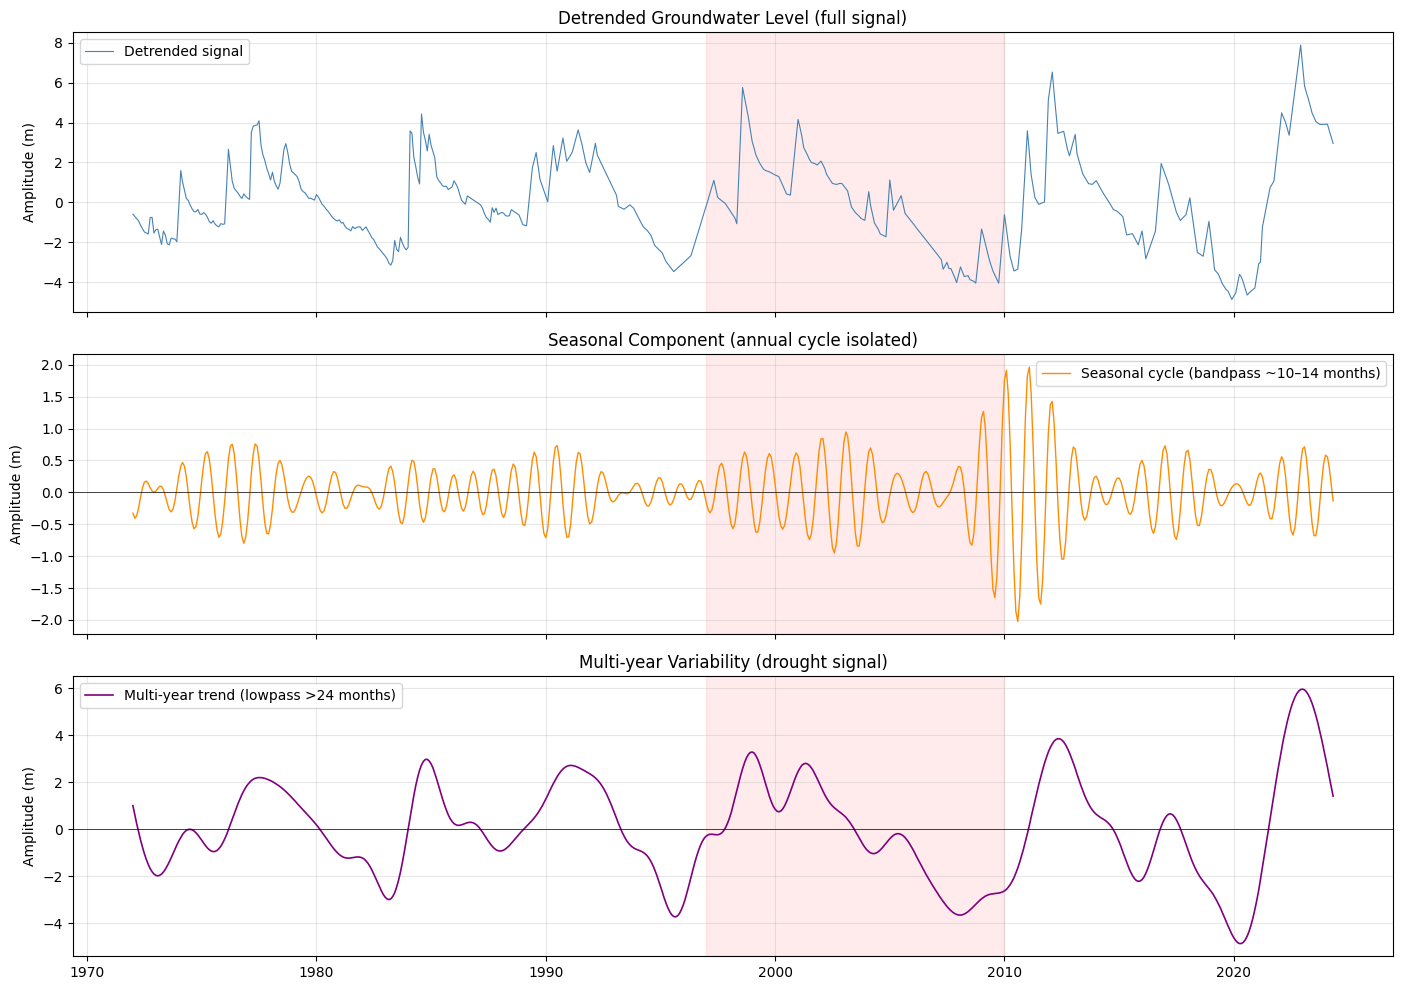

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# some AI help converting time and detrending data

# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['RSWL_mAHD'].values

# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit linear trend
trend = np.polyval(pp, time)
detrended = signal - trend

# From class content
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
periods = 1 / freqs[1:]
amps_plot = amps[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow a couple months on either sied
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Groundwater Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Rainfall Frequency Analysis

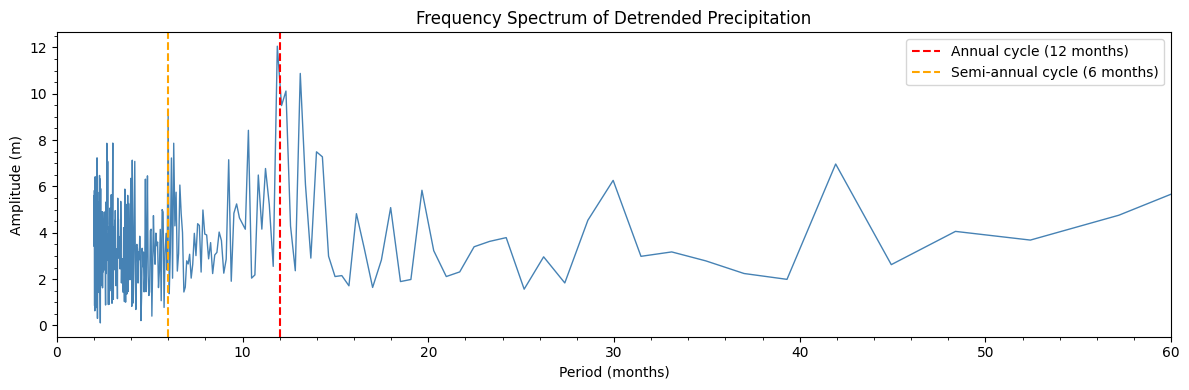

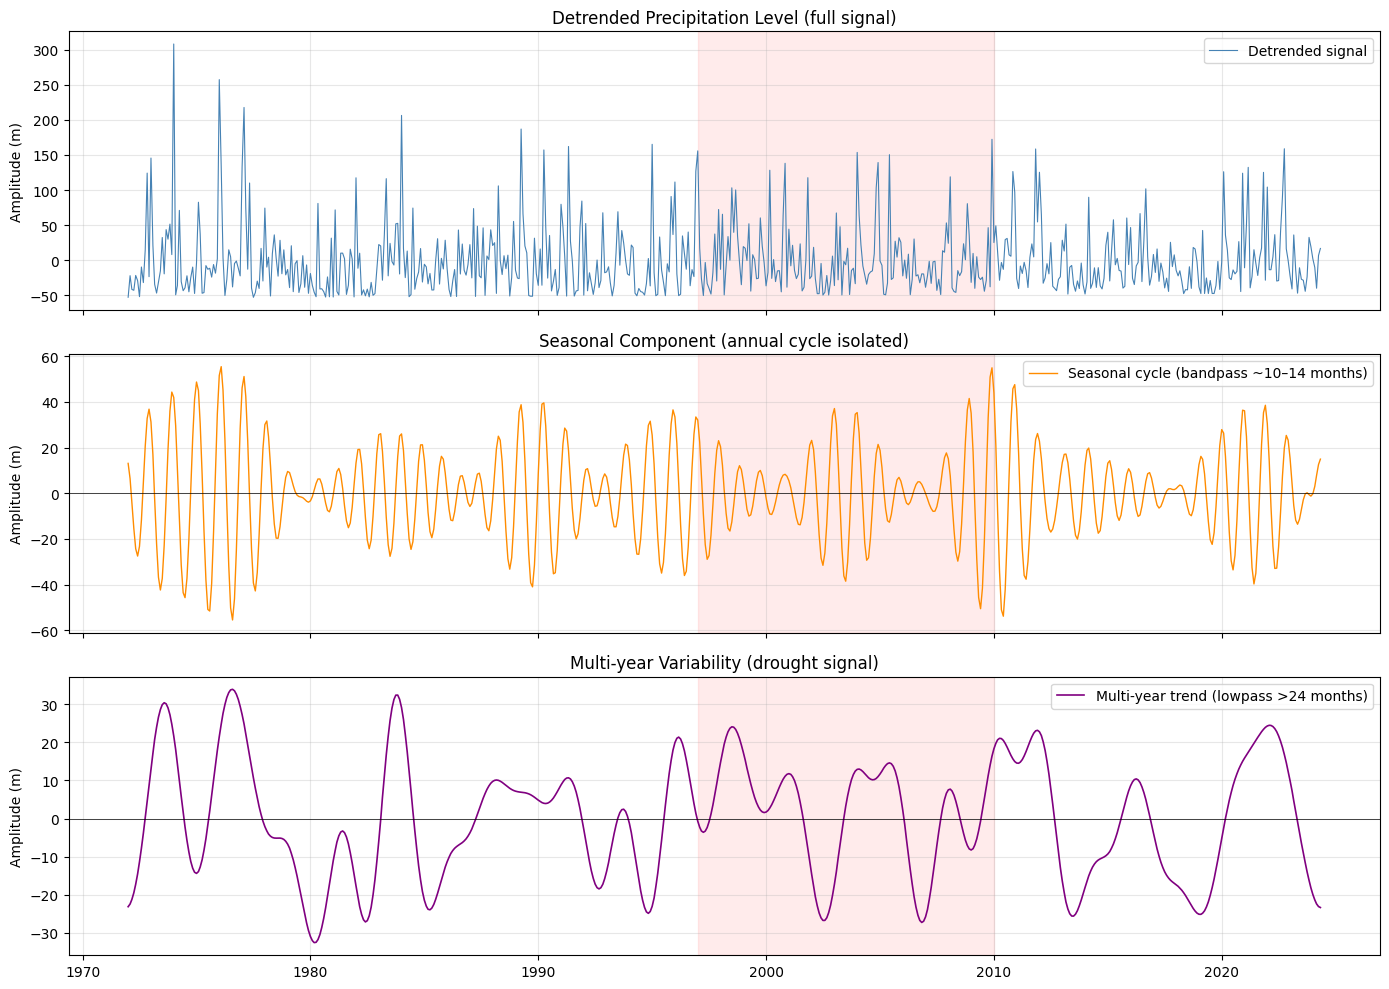

In [9]:
# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['daily_rain'].values

# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)
trend = np.polyval(pp, time)
detrended = signal - trend

freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
# Ignore the zero-frequency (DC) component at freqs[0]
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Precipitation')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Precipitation Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Evaporation Frequency Analysis

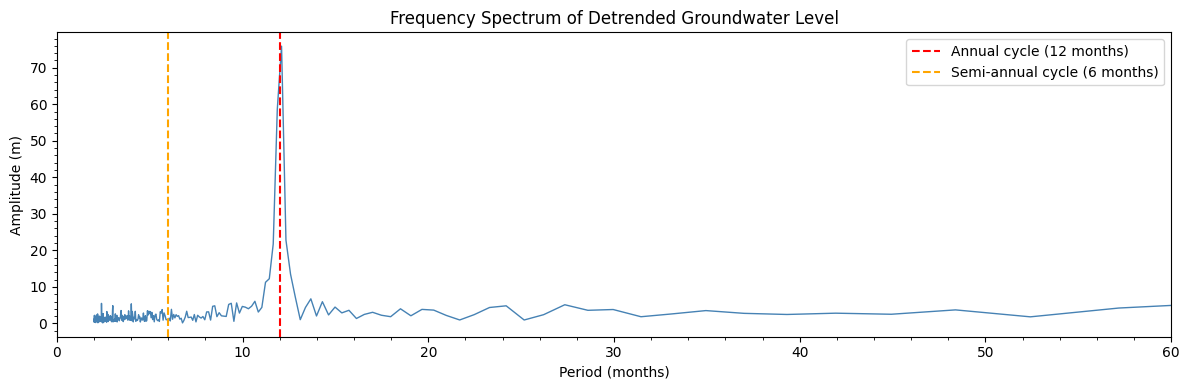

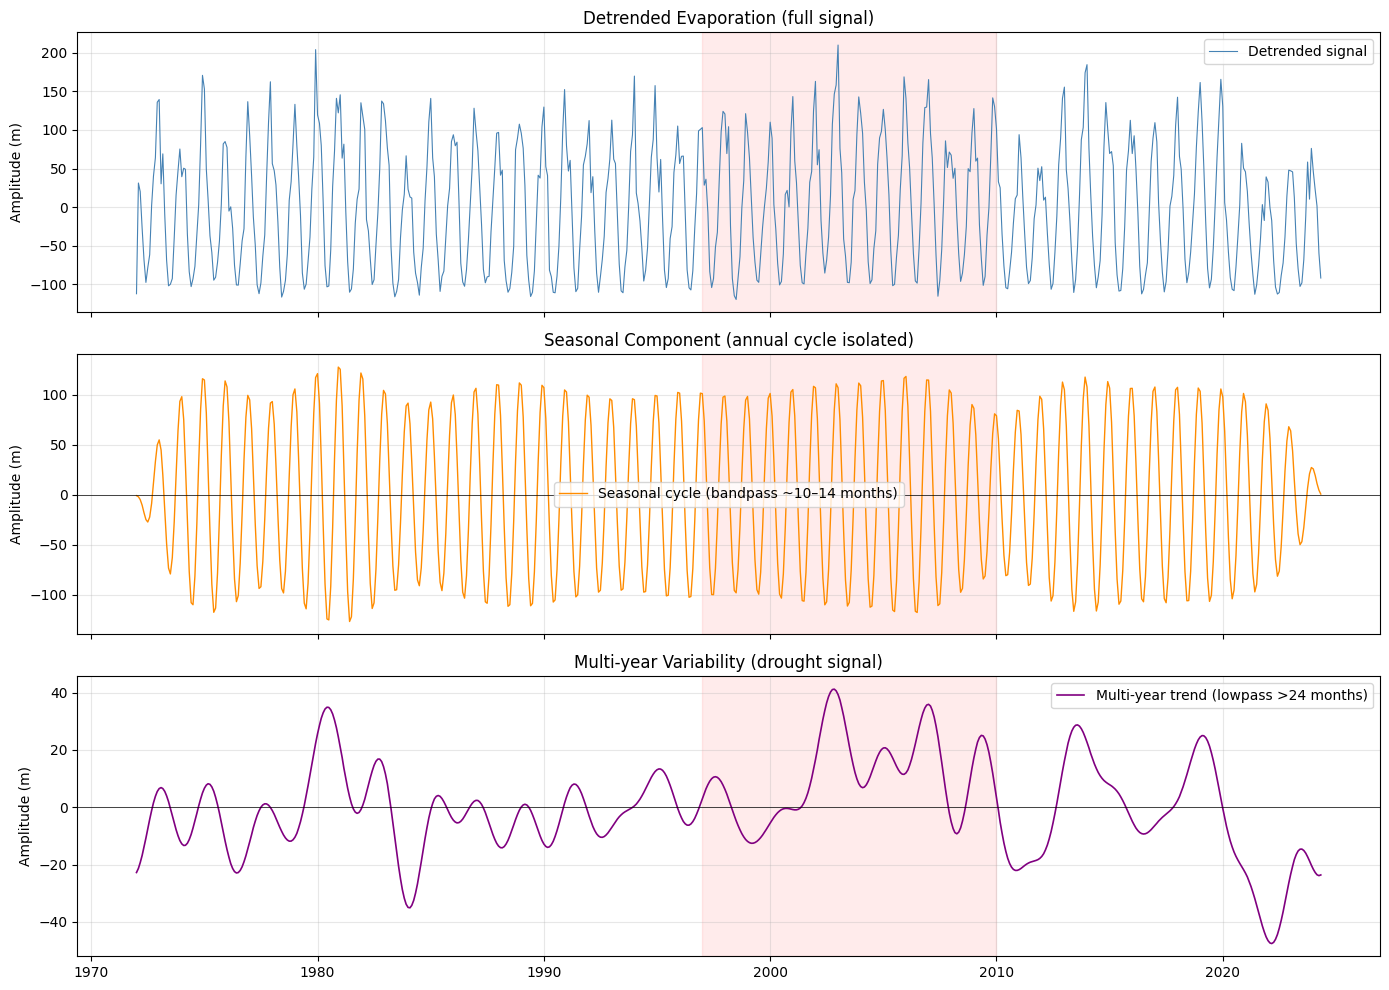

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['evap_pan'].values
# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit degree-1 polynomial (linear trend)
trend = np.polyval(pp, time)
detrended = signal - trend

# From your class code
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Evaporation (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Temperature Frequency Analysis

#### Evapotranspiration Frequency Analysis

### Cross Correlation Determination
Determine cross correlation between rainfall and groundwater - what is the lag?

Rainfall

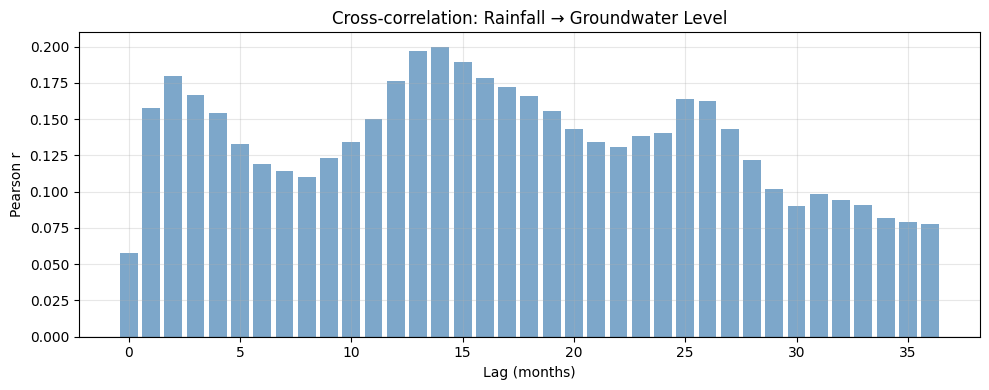

Strongest correlation at lag = 14.0 months, r = 0.200, p = 0.0000


In [113]:
from scipy import stats
import numpy as np

# Cross-correlation: how well does rainfall at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['daily_rain'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'daily_rain']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['daily_rain'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['daily_rain'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Rainfall → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_rain = lag_df.loc[lag_df['r'].idxmax()]

best_lag_rain_months = int(best_lag_rain['lag_months'])

print(f"Strongest correlation at lag = {best_lag_rain['lag_months']} months, r = {best_lag_rain['r']:.3f}, p = {best_lag_rain['p_value']:.4f}")

Evaporation

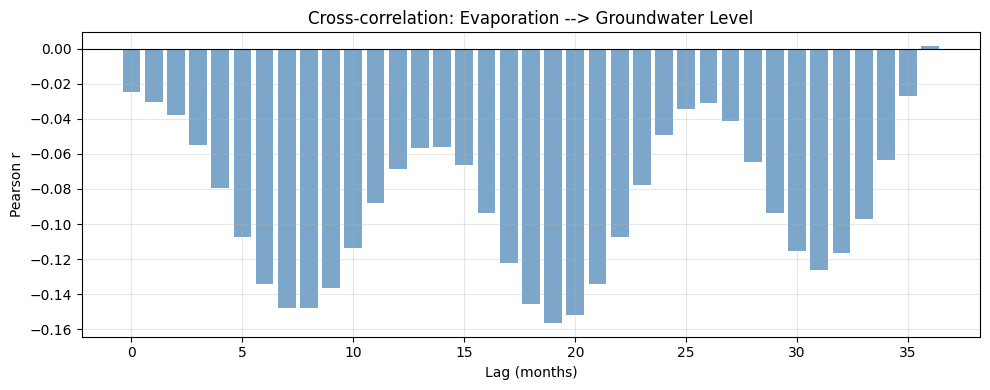

Strongest correlation at lag = 19.0 months, r = -0.156, p = 0.0001


In [114]:
# Cross-correlation: how well does evaporation at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['evap_pan'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'evap_pan']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['evap_pan'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['evap_pan'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Evaporation --> Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_evap = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_evap_months = int(best_lag_evap['lag_months'])

print(f"Strongest correlation at lag = {best_lag_evap['lag_months']} months, r = {best_lag_evap['r']:.3f}, p = {best_lag_evap['p_value']:.4f}")

Temperature

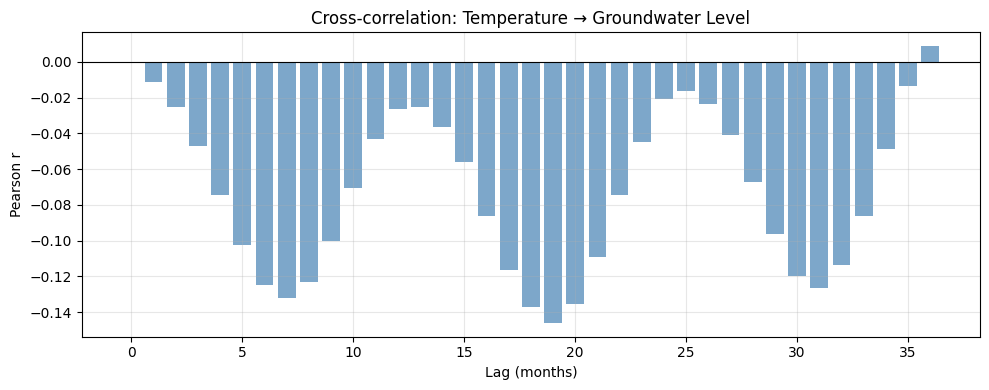

Strongest correlation at lag = 19 months, r = -0.146, p = 0.0003


In [115]:
# Cross-correlation: how well does temperature at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['max_temp'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'max_temp']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['max_temp'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['max_temp'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Temperature → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_temp = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_temp_months = int(best_lag_temp['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp_months} months, "
      f"r = {best_lag_temp['r']:.3f}, "
      f"p = {best_lag_temp['p_value']:.4f}")

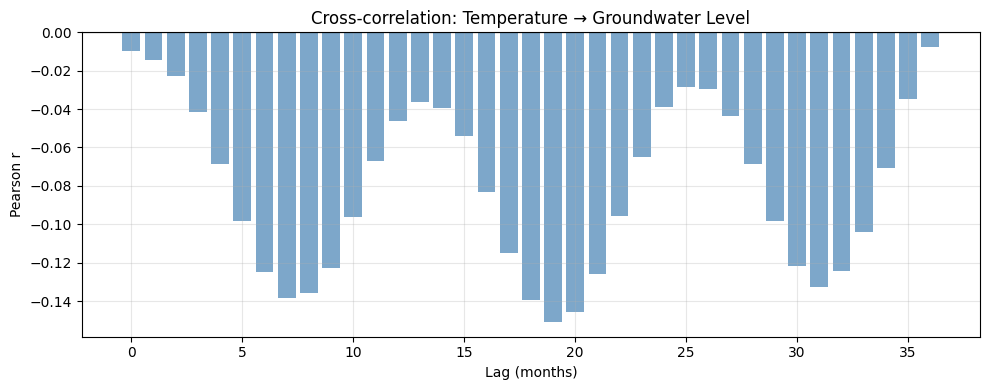

Strongest correlation at lag = 19.0 months, r = -0.156, p = 0.0001


In [116]:
# Cross-correlation: how well does temperature at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['et_short_crop'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'et_short_crop']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['et_short_crop'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['et_short_crop'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Temperature → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_et = lag_df.loc[lag_df['r'].abs().idxmax()]
best_lag_et_months = int(best_lag_et['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp['lag_months']} months, r = {best_lag['r']:.3f}, p = {best_lag['p_value']:.4f}")

###Extract optimal lag and build lagged dataset

In [117]:
print(f"Optimal lag — Rainfall:            {best_lag_rain_months} months")
print(f"Optimal lag — Evapotranspiration:  {best_lag_evap_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_temp_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_et_months} months")

Optimal lag — Rainfall:            14 months
Optimal lag — Evapotranspiration:  19 months
Optimal lag — Max Temperature:     19 months
Optimal lag — Max Temperature:     19 months


In [118]:
df_lagged = pd.DataFrame(index=df.index)

df_lagged['RSWL_mAHD'] = df['RSWL_mAHD']

# Shift each predictor back by its optimal lag:
# .shift(n) moves values forward n rows, so row t gets the value from t-n
# which means groundwater at t is paired with rainfall at t - lag (correct direction)
df_lagged["rainfall_lagged"] = df['daily_rain'].shift(best_lag_rain_months)
df_lagged['evap_lagged']       = df['evap_pan'].shift(best_lag_evap_months)
df_lagged['temp_lagged']     = df['max_temp'].shift(best_lag_temp_months)
df_lagged['et_lagged']     = df['et_short_crop'].shift(best_lag_et_months)


# Drop rows where any lagged column is NaN
# (the first max_lag rows will be NaN due to shifting)
df_lagged = df_lagged.dropna()

print(f"\nLagged dataset shape: {df_lagged.shape}")
print(f"Date range: {df_lagged.index.min()} to {df_lagged.index.max()}")
print(df_lagged.head())


Lagged dataset shape: (610, 5)
Date range: 1973-08-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  rainfall_lagged  evap_lagged  temp_lagged  et_lagged
Date                                                                       
1973-08-01     186.89             24.4         54.3    30.962500       47.5
1973-09-01     187.22              1.6        197.8    31.268966      165.3
1973-10-01     187.18             43.8        186.7    31.448387      162.4
1973-11-01     187.16             21.6        139.2    26.403333      110.7
1973-12-01     187.02             68.1         98.4    22.900000       79.7


#Analysis - Regression Correlation

#####Install bambi

In [119]:
!pip install bambi #system command to install bambi package

In [120]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

###Single Regression (Rainfall)

Sample correlation r = 0.20
Sample correlation R^2 = 0.04


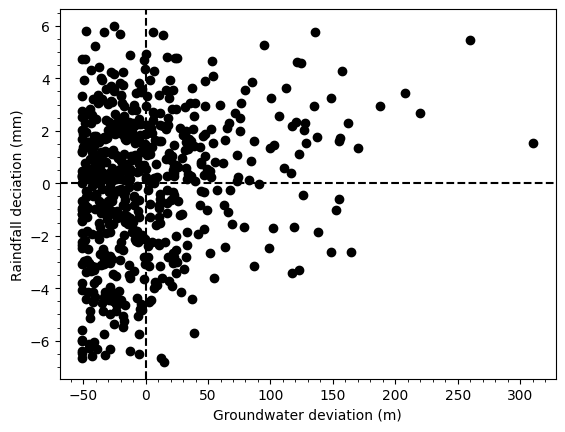

In [121]:
# Extract data for regression
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']


y = groundwater_level - np.mean(groundwater_level) #deviation in the x variable
x = rainfall_lagged - np.mean(rainfall_lagged) #deviation in the y variable
plt.plot(x,y,'ok') #plot the deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.xlabel('Groundwater deviation (m)') #label the x-axis
plt.ylabel('Raindfall deciation (mm)') #label the y-axis
plt.minorticks_on() #include minor ticks

num = np.sum(x*y) #find the numerator
den = np.sqrt(np.sum(x**2)) * np.sqrt(np.sum(y**2)) #find the denominator
r = num/den #obtain r
print('Sample correlation r = {:.2f}'.format(r)) #print result to 2 d.p.
r2 = r**2
print('Sample correlation R^2 = {:.2f}'.format(r2)) #print result to 2 d.p.

Scale the x values

In [122]:
data = pd.DataFrame({"y": rainfall_lagged}) #define the y-variable
data["x_scaled"] = (groundwater_level-np.mean(groundwater_level)) / np.std(groundwater_level) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

In [123]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False) # records logarithm of likelihood

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [124]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

           rank    elpd    p  elpd_diff  weight    se   dse  warning
linear        0 -3250.0  5.2        0.0     1.0  32.0  0.00    False
quadratic     1 -3250.0  6.5       -1.1     0.0  32.0  0.31    False
cubic         2 -3260.0  7.6       -2.0     0.0  32.0  1.00    False
quartic       3 -3260.0  8.8       -2.0     0.0  32.0  1.30    False


Text(0, 0.5, 'Rainfall')

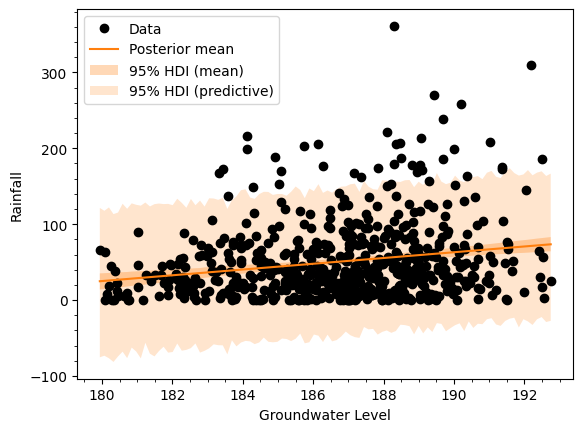

In [125]:
x_range = np.linspace(groundwater_level.min(), groundwater_level.max(), 100) # Predict across a range of distances values from 0 to 40
x_range_scaled = (x_range-np.mean(groundwater_level)) / np.std(groundwater_level) #we need to apply the same scaling as above

new_data = pd.DataFrame({"x_scaled": x_range_scaled}) #dataframe with the new x-values
model_linear.predict(idata_linear, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_linear.predict(idata_linear, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
#posterior_mean = y_pps_draws.mean(axis=0)
posterior_mean = y_mean_draws.mean(axis=0)
hdi_mean = az.hdi(
    y_mean_draws,
    prob=0.95, axis=0)
hdi_pps = az.hdi(
    y_pps_draws,
    prob=0.95, axis=0)

# Plot both posterior for regression lines and the observations
plt.plot(groundwater_level, rainfall_lagged, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Groundwater Level')
plt.ylabel('Rainfall')

### Multi Regression

In [126]:
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']
temp_lagged = df_lagged['temp_lagged']
evap_lagged = df_lagged['evap_lagged']
et_lagged = df_lagged['et_lagged']

# Response variable (groundwater)
data = pd.DataFrame({
    "y": groundwater_level
})

# Standardised predictors
data["rain_scaled"] = (
    rainfall_lagged - np.mean(rainfall_lagged)
) / np.std(rainfall_lagged)

data["temp_scaled"] = (
    temp_lagged - np.mean(temp_lagged)
) / np.std(temp_lagged)

data["et_scaled"] = (
    et_lagged - np.mean(et_lagged)
) / np.std(et_lagged)

data["evap_scaled"] = (
    evap_lagged - np.mean(evap_lagged)
) / np.std(evap_lagged)

In [127]:
## Correlation Matrix
corr = data[[
    "rain_scaled",
    "temp_scaled",
    "et_scaled",
    "evap_scaled"
]].corr()

print(corr)

             rain_scaled  temp_scaled  et_scaled  evap_scaled
rain_scaled     1.000000    -0.221900  -0.189830    -0.187518
temp_scaled    -0.221900     1.000000   0.955880     0.942587
et_scaled      -0.189830     0.955880   1.000000     0.986231
evap_scaled    -0.187518     0.942587   0.986231     1.000000


Interpretation:

|r| < 0.5 → weak/moderate correlation

0.5–0.7 → notable correlation

0.7 → strong multicollinearity concern
- ET and temperature strongly correlated
- Pan evaporation and ET strongly correlated
---

Multiple Regression Model
- direct extension of linear models discussed in class

In [128]:
model_multi = bmb.Model(
    "y ~ rain_scaled + temp_scaled + et_scaled + evap_scaled",
    data
)

idata_multi = model_multi.fit(
    idata_kwargs={"log_likelihood": True},
    progressbar=False
)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


In [129]:
# Extract coefficients
summary = az.summary(
    idata_multi,
    var_names=[
        "rain_scaled",
        "temp_scaled",
        "et_scaled",
        "evap_scaled"
    ]
)

print(summary)

              mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
rain_scaled  0.492  0.108     0.32     0.67      2104      1418  1.00   
temp_scaled   0.17   0.36    -0.41     0.72      1589      1293  1.00   
et_scaled     0.22   0.71    -0.95      1.4      1544      1186  1.00   
evap_scaled  -0.71   0.63     -1.7      0.3      1654      1470  1.00   

            mcse_mean mcse_sd  
rain_scaled    0.0024  0.0018  
temp_scaled    0.0092  0.0068  
et_scaled       0.018   0.012  
evap_scaled     0.016   0.011  


Interpretation
- these coefficients are not correlation (they are partial regression coefficients ie. the independent effects after controlling for other variables)
- better than simple R values
- measures independent contribution after accounting for overlap with other predictors THEREFORE more defensible for this groundwater case

In [130]:
# Actual correlation variables
variables = {
    "Rainfall": rainfall_lagged,
    "Temperature": temp_lagged,
    "ET": et_lagged,
    "Pan evaporation": evap_lagged
}

for name, var in variables.items():

    x = groundwater_level - np.mean(groundwater_level)
    y = var - np.mean(var)

    r = np.sum(x*y) / (
        np.sqrt(np.sum(x**2)) *
        np.sqrt(np.sum(y**2))
    )

    print(f"{name}:")
    print(f"r = {r:.2f}")
    print(f"R² = {r**2:.2f}")
    print()

Rainfall:
r = 0.20
R² = 0.04

Temperature:
r = -0.15
R² = 0.02

ET:
r = -0.15
R² = 0.02

Pan evaporation:
r = -0.16
R² = 0.02



Interpretation
- measures total association (including shared climatic effects)

####Visualise Regression

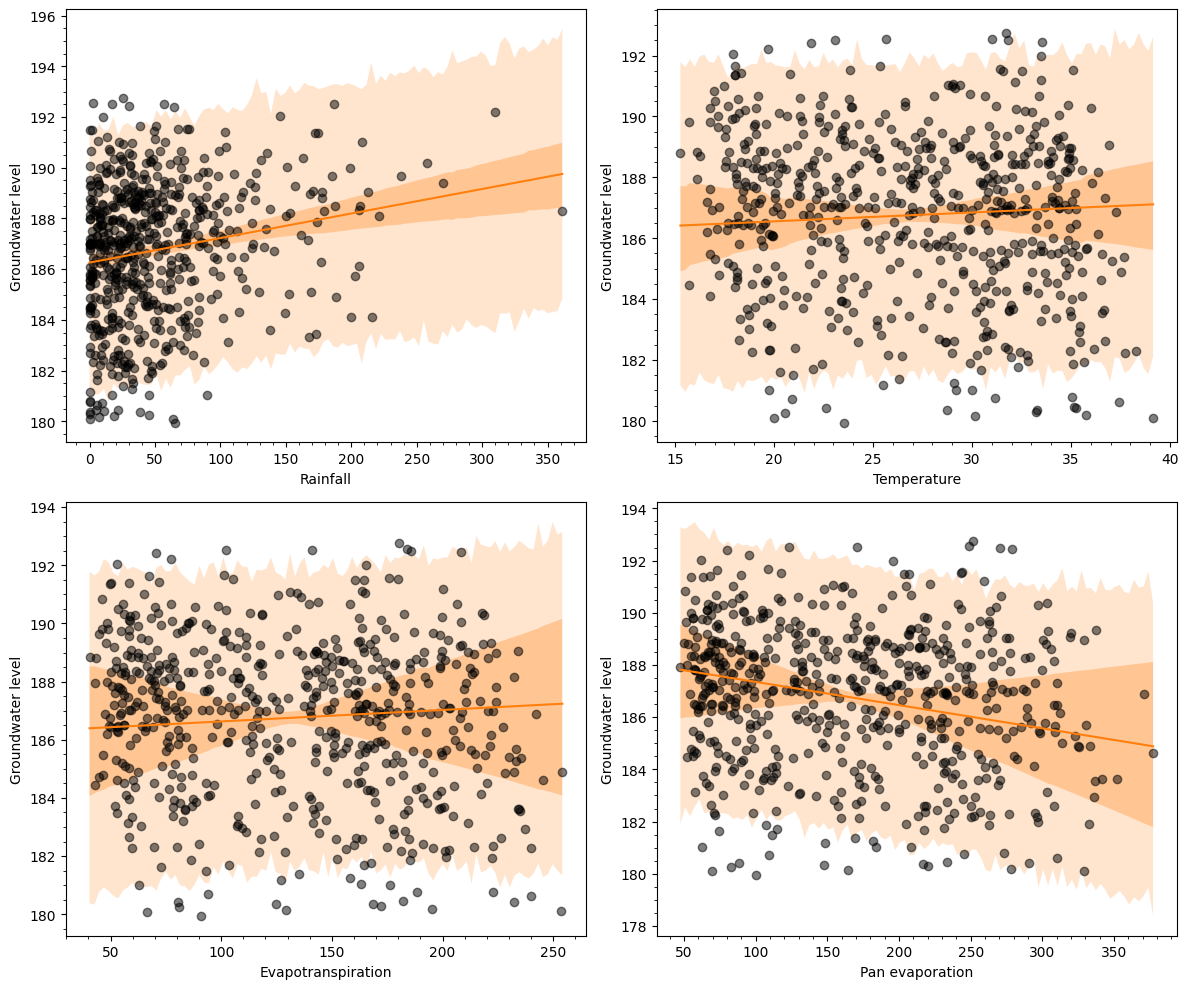

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictors = [
    ("rain_scaled", rainfall_lagged, "Rainfall"),
    ("temp_scaled", temp_lagged, "Temperature"),
    ("et_scaled", et_lagged, "Evapotranspiration"),
    ("evap_scaled", evap_lagged, "Pan evaporation")
]

axes = axes.flatten()

for ax, (var_name, raw_data, label) in zip(axes, predictors):

    # Create prediction range for this variable
    x_range = np.linspace(raw_data.min(), raw_data.max(), 100)

    # Scale using same transformation as model fitting
    x_scaled = (
        x_range - np.mean(raw_data)
    ) / np.std(raw_data)

    # Hold all predictors at mean = 0
    new_data = pd.DataFrame({
        "rain_scaled": np.zeros(len(x_range)),
        "temp_scaled": np.zeros(len(x_range)),
        "et_scaled": np.zeros(len(x_range)),
        "evap_scaled": np.zeros(len(x_range))
    })

    # Vary only the predictor of interest
    new_data[var_name] = x_scaled

    # Generate predictions
    model_multi.predict(
        idata_multi,
        data=new_data,
        kind='response_params'
    )

    model_multi.predict(
        idata_multi,
        data=new_data,
        kind='response'
    )

    # Posterior draws
    y_mean_draws = idata_multi.posterior["mu"].values
    y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

    y_pps_draws = idata_multi.posterior_predictive["y"].values
    y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

    # Mean + HDI
    posterior_mean = y_mean_draws.mean(axis=0)

    hdi_mean = az.hdi(
        y_mean_draws,
        prob=0.95,
        axis=0
    )

    hdi_pps = az.hdi(
        y_pps_draws,
        prob=0.95,
        axis=0
    )

    # Plot observations
    ax.plot(raw_data, groundwater_level, 'ok', alpha=0.5)

    # Posterior mean
    ax.plot(
        x_range,
        posterior_mean,
        color="C1",
        label="Posterior mean"
    )

    # HDI mean
    ax.fill_between(
        x_range,
        hdi_mean[:, 0],
        hdi_mean[:, 1],
        alpha=0.3,
        color="C1",
        edgecolor=None
    )

    # Predictive HDI
    ax.fill_between(
        x_range,
        hdi_pps[:, 0],
        hdi_pps[:, 1],
        alpha=0.2,
        color="C1",
        edgecolor=None
    )

    ax.set_xlabel(label)
    ax.set_ylabel("Groundwater level")
    ax.minorticks_on()

plt.tight_layout()
plt.show()

Partial Regression Plots
- each pannel shows the relationship between groundwater and this variable, after controlling for all other climatic variables
- more powerful than seperate bivariate regressions

### Overall Interpretation of Muli-variable Regression:

**Extracter Coefficients**

Rainfal = +0.49
Temperature = +0.18
ET = +0.25
Pan evaporation = -0.74
- predictors have been standardaised so they represent the groundwater response (in m) to one standard deviation increase in the predictor

Randfall
- clearest signal = strongest independent recharge control
- uncertainly interval doesn't overlap zero much

Temperature
- weak and highly uncertain
- interval spans negative and positive values
- contributes little alone (reflects multicollinearity)

Evapotranspiration
- surprising result as ET usually reduces groundwater
- likely because ET is strongly correlated with rainfall seasonality and this model struggles to seperate it
- the extremely wide uncertainty interval confirms this instability

Pan Evaporation
- strongest negative relationship = dominant groundwater loss mechanism
- higher evaporative demans reduces groundwater use
- uncertainty is large however the negative trend is meaningful

**Simple Correlations**
- fairly weak
- no simple climatic variable strongly explains groundwater independently

**Overall**

Simple correlation: shared association between two variables
- overall climatic association

Multiple regression coefficient: indepdendent effect of predictor after controlling for other factors
- isolate independent groundwater contribution
- however in the cases of temp and ET multicollinearity limits interpretation of individual climatic predictors

**Application to model**
Muli-regression coefficients are more appropriate for weighting factors in the groundwater storage model

#Model Creation

### Concept

The basic model concept is $$ΔS=Recharge−Discharge$$

Components of recharge include:
- rainfall
  - infiltration (percolation and interflow)
- stream loss

Components of discharge include
- pumping
- baseflow (flow from aquifer to stream)
- ET and evaporation loss (in a shallow unconfined aquifer system these factors remove water directly from saturated soil/shallow aquifers)
  - evapotranspiration (capillary rise)
  - evaporation (induced upwelling and removing rainfal before it can infiltrate into groundwater system)

---
To convert storage to height we can use the specific yield (how much water must be added/removed to change the groundwater level)

$$Δh=​ΔS/S_y​$$
where:
$$Δh$$ = groundwater level change
$$ΔS$$ = storage change
$$S_y$$ = specific yield

Note: it will be important here to convert from units of storage (mm) to hight (m)

---
**Variables**

Specific Yield: #0.05 - 0.3 for the Narrabri formation (where the groundwater site is located)

Recharge Fraction: the fraction of rainfall that becomes groundwater recharge (ie. the amount that infiltrates)

---
For each month
storage_new = storage_old + recharge - discharge

In [135]:
## Model Data Frame
model_data = pd.DataFrame({
    "groundwater": groundwater_level,
    "rainfall": rainfall_lagged,
    "et": et_lagged,
    "temp": temp_lagged,
    "evap": evap_lagged
}).dropna()

## Set coefficient weights (from regression above)
rain_coef = 0.49
temp_coef = 0.18
et_coef = 0.25
evap_coef = -0.74

Visualisation of regression coefficients

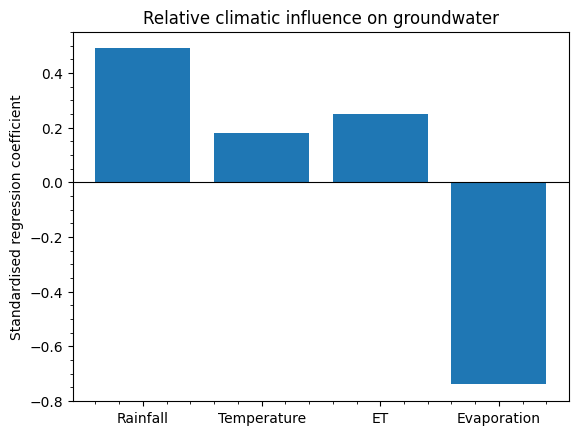

In [162]:
drivers = ["Rainfall", "Temperature", "ET", "Evaporation"]
coefficients = [rain_coef, temp_coef, et_coef, evap_coef]

plt.bar(drivers, coefficients)
plt.axhline(0, color="k", linewidth=0.8)
plt.ylabel("Standardised regression coefficient")
plt.title("Relative climatic influence on groundwater")
plt.minorticks_on()
plt.show()

### Simple Model Function

In [137]:
recharge_weight = abs(rain_coef)
discharge_weight = abs(et_coef) + abs(evap_coef)

print(recharge_weight)
print(discharge_weight)

0.49
0.99


Simple groundwater model
- note: AI used to help me understand how to allow the data to contribute to the step model

In [138]:
# Set up the groundwater model as a function so that it can be run with
# varied inputs in the analysis
def run_groundwater_model(data, recharge_fraction, specific_yield):

    # Integrate data into the model
    rainfall = data["rainfall"].values
    et = data["et"].values
    evap = data["evap"].values
    observed_gw = data["groundwater"].values

    # Start model at observed initial groundwater level
    groundwater_model = []
    gw = observed_gw[0]

    groundwater_model.append(gw)

    for step in range(1, len(data)):

        # Recharge term: fraction of rainfall becomes recharge
        recharge = recharge_fraction * rainfall[step] * recharge_weight

        # Climate discharge term: ET + evaporation remove water
        discharge = recharge_fraction * (
            et[step] * abs(et_coef) +
            evap[step] * abs(evap_coef)
        )

        # Change in storage, in mm
        delta_storage_mm = recharge - discharge

        # Convert storage change to groundwater level change, in metres
        delta_gw_m = (delta_storage_mm / 1000) / specific_yield

        # Update groundwater level
        gw = gw + delta_gw_m
        groundwater_model.append(gw)
        # this is the equivalend of T = T_new, T_output.append(...)

    return np.array(groundwater_model)

Test model run

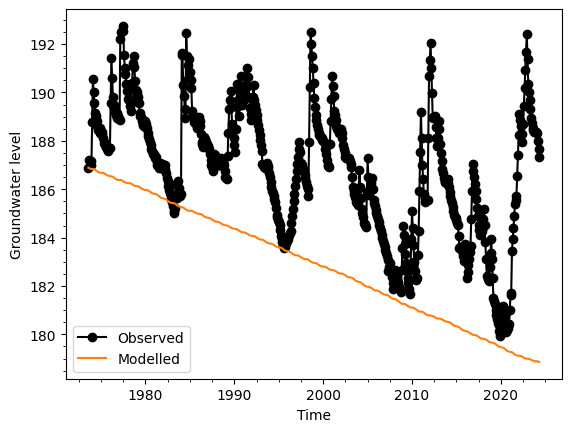

In [143]:
recharge_fraction = 0.01
specific_yield = 0.1

gw_modelled = run_groundwater_model(
    model_data,
    recharge_fraction,
    specific_yield
)

plt.plot(model_data.index, model_data["groundwater"], 'ok-', label="Observed")
plt.plot(model_data.index, gw_modelled, color="C1", label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.legend()
plt.minorticks_on()
plt.show()

### Calculate RMSE and R^2

Introduce calculated parameters to compare the model to observed data:

RMSE is the root mean square error

- measures the typical difference between the modelled and observed groundwater level
- a smaller RMSE correlates to a better model (eg. RMSE = 0.25 means the model is wrong by 0.25m)

R^2 measures how much of the observed variation is explained by the model
- the closer the 1 indicates a better model fit

In [141]:
observed = model_data["groundwater"].values
modelled = gw_modelled

rmse = np.sqrt(np.mean((observed - modelled)**2))

r = np.corrcoef(observed, modelled)[0, 1]
r2 = r**2

print(f"RMSE = {rmse:.3f}")
print(f"R² = {r2:.3f}")

RMSE = 45.506
R² = 0.274


### Calibrate Model Parameters

Simple nested for loop structure to compare different parameter values. Compare against the RMSE

In [144]:
recharge_values = np.linspace(0.01, 0.3, 30)
specific_yield_values = np.linspace(0.05, 0.2, 30)

best_rmse = np.inf
best_recharge = None
best_sy = None
best_model = None

for recharge_fraction in recharge_values:

    for specific_yield in specific_yield_values:

        gw_modelled = run_groundwater_model(
            model_data,
            recharge_fraction,
            specific_yield
        )

        observed = model_data["groundwater"].values
        rmse = np.sqrt(np.mean((observed - gw_modelled)**2))

        if rmse < best_rmse:
            best_rmse = rmse
            best_recharge = recharge_fraction
            best_sy = specific_yield
            best_model = gw_modelled

print(f"Best recharge fraction = {best_recharge:.3f}")
print(f"Best specific yield = {best_sy:.3f}")
print(f"Best RMSE = {best_rmse:.3f}")

Best recharge fraction = 0.010
Best specific yield = 0.200
Best RMSE = 2.960


### Plot Best Model against Observations

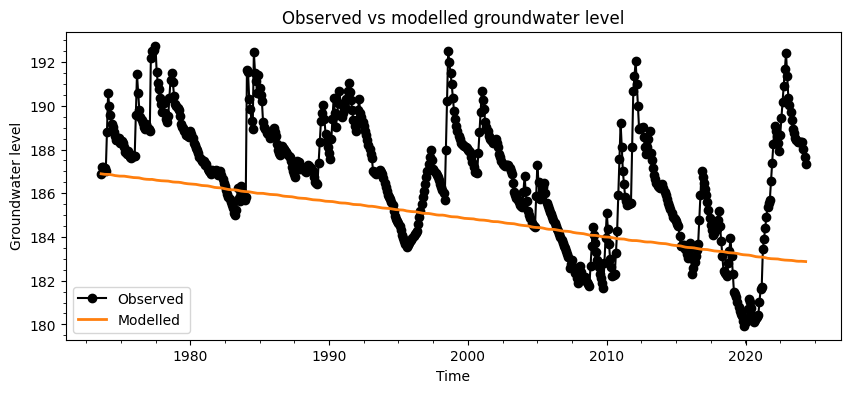

In [145]:
plt.figure(figsize=(10, 4))

plt.plot(model_data.index, model_data["groundwater"], 'ok-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", linewidth=2, label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Observed vs modelled groundwater level")
plt.legend()
plt.minorticks_on()
plt.show()

In [146]:
observed = model_data["groundwater"].values

rmse = np.sqrt(np.mean((observed - best_model)**2))
r = np.corrcoef(observed, best_model)[0, 1]
r2 = r**2

print(f"Final RMSE = {rmse:.3f}")
print(f"Final R² = {r2:.3f}")

Final RMSE = 2.960
Final R² = 0.274


### Simple Scenarios

20% rainfall reduction

In [147]:
scenario_dry = model_data.copy()
scenario_dry["rainfall"] = scenario_dry["rainfall"] * 0.8

gw_dry = run_groundwater_model(
    scenario_dry,
    best_recharge,
    best_sy
)

20% evaporation increase

In [148]:
scenario_hot = model_data.copy()
scenario_hot["evap"] = scenario_hot["evap"] * 1.2
scenario_hot["et"] = scenario_hot["et"] * 1.2

gw_hot = run_groundwater_model(
    scenario_hot,
    best_recharge,
    best_sy
)

Plot

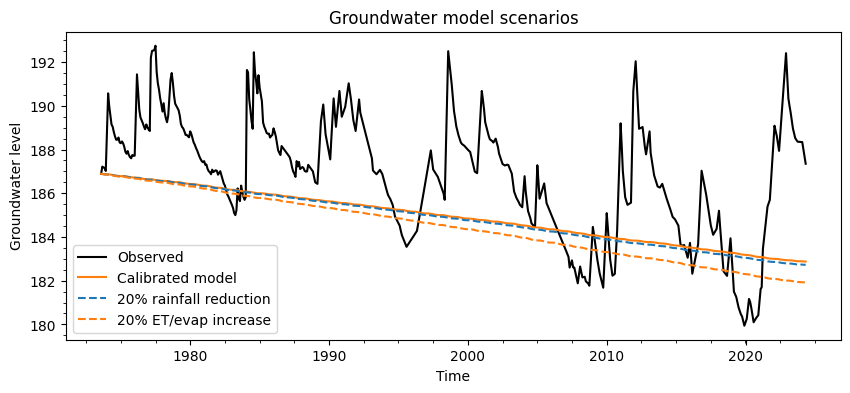

In [149]:
plt.figure(figsize=(10, 4))

plt.plot(model_data.index, model_data["groundwater"], 'k-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", label="Calibrated model")
plt.plot(model_data.index, gw_dry, '--', label="20% rainfall reduction")
plt.plot(model_data.index, gw_hot, '--', label="20% ET/evap increase")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model scenarios")
plt.legend()
plt.minorticks_on()
plt.show()

### Pumping Model

Add a pumping term to the model in mm/month

In [152]:
def run_groundwater_model_pumping(data, recharge_fraction, specific_yield, pumping_rate=0):

    rainfall = data["rainfall"].values
    et = data["et"].values
    evap = data["evap"].values
    observed_gw = data["groundwater"].values

    groundwater_model = []
    gw = observed_gw[0]

    groundwater_model.append(gw)

    for step in range(1, len(data)):

        recharge = recharge_fraction * rainfall[step] * abs(rain_coef)

        climate_discharge = (
            et[step] * abs(et_coef) +
            evap[step] * abs(evap_coef)
        )

        discharge = recharge_fraction * climate_discharge + pumping_rate

        delta_storage_mm = recharge - discharge

        delta_gw_m = (delta_storage_mm / 1000) / specific_yield

        gw = gw + delta_gw_m

        groundwater_model.append(gw)

    return np.array(groundwater_model)

Calibrate including pumping term

In [153]:
recharge_values = np.linspace(0.01, 0.3, 30)
specific_yield_values = np.linspace(0.05, 0.2, 30)
pumping_values = np.linspace(0, 20, 21)

best_rmse = np.inf
best_recharge = None
best_sy = None
best_pumping = None
best_model = None

for recharge_fraction in recharge_values:

    for specific_yield in specific_yield_values:

        for pumping_rate in pumping_values:

            gw_modelled = run_groundwater_model_pumping(
                model_data,
                recharge_fraction,
                specific_yield,
                pumping_rate
            )

            observed = model_data["groundwater"].values
            rmse = np.sqrt(np.mean((observed - gw_modelled)**2))

            if rmse < best_rmse:

                best_rmse = rmse
                best_recharge = recharge_fraction
                best_sy = specific_yield
                best_pumping = pumping_rate
                best_model = gw_modelled

print(f"Best recharge fraction = {best_recharge:.3f}")
print(f"Best specific yield = {best_sy:.3f}")
print(f"Best pumping rate = {best_pumping:.1f} mm/month")
print(f"Best RMSE = {best_rmse:.3f}")

Best recharge fraction = 0.010
Best specific yield = 0.200
Best pumping rate = 0.0 mm/month
Best RMSE = 2.960


This indicates that this aquifer is ONLY controlled by climatic/natural system flows

#### Pumping Scenarios

Scenario: groundwater extraction for irrigation

JUSTIFY PUMPING ESTIMATES

In [157]:
scenario_pump = model_data.copy()

gw_pump1 = run_groundwater_model_pumping(
    scenario_pump,
    best_recharge,
    best_sy,
    pumping_rate=5
)

gw_pump2 = run_groundwater_model_pumping(
    scenario_pump,
    best_recharge,
    best_sy,
    pumping_rate=15
)

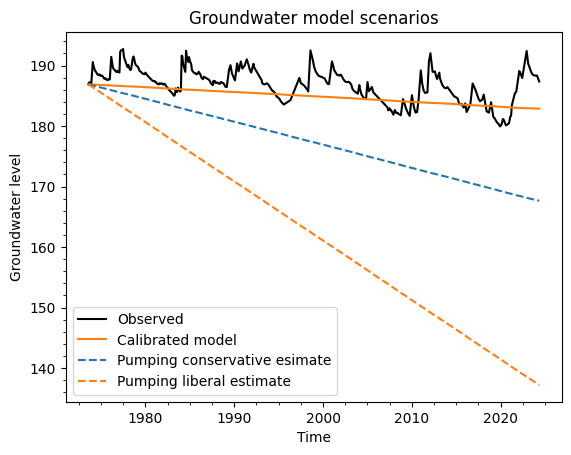

In [158]:
plt.plot(model_data.index, model_data["groundwater"], 'k-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", label="Calibrated model")
plt.plot(model_data.index, gw_pump1, '--', label="Pumping conservative esimate")
plt.plot(model_data.index, gw_pump2, '--', label="Pumping liberal estimate")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model scenarios")
plt.legend()
plt.minorticks_on()
plt.show()

### Millennium Drought Scenario

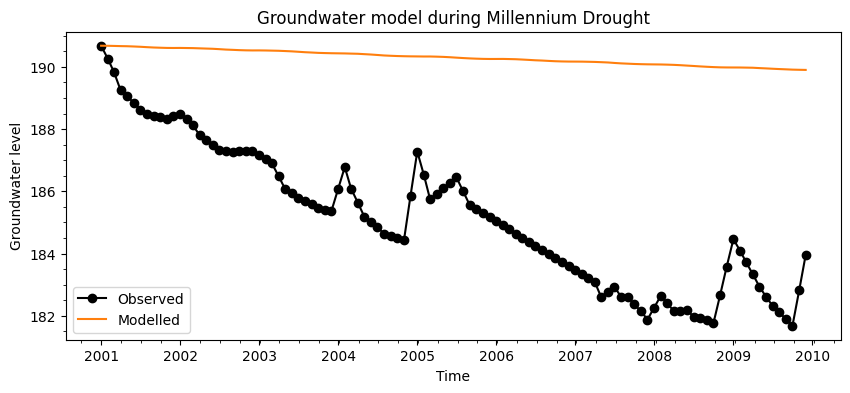

In [170]:
# Limit the model data to the Millenium Drought time period (peak drought from 2001 to 2009)
model_data.index = pd.to_datetime(model_data.index)
drought_data = model_data.loc["2001":"2009"].copy()

gw_drought = run_groundwater_model(
    drought_data,
    best_recharge,
    best_sy,
    best_pumping
)
plt.figure(figsize=(10, 4))

plt.plot(drought_data.index, drought_data["groundwater"], 'ok-', label="Observed")
plt.plot(drought_data.index, gw_drought, color="C1", label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model during Millennium Drought")
plt.legend()
plt.minorticks_on()
plt.show()

In [171]:
full_mean = model_data[["rainfall", "et", "evap"]].mean()
drought_mean = drought_data[["rainfall", "et", "evap"]].mean()

change_percent = 100 * (drought_mean - full_mean) / full_mean

print(change_percent)

rainfall   -6.223644
et          3.557116
evap        7.992653
dtype: float64


The drought period had 6% less rainfall, 3% more evapotranspiration and 8% more evaporation

### Future Scenarios

Can we use this model to predict how the groundwater system will behave far into the future?

Using a simple approach to use recent climate averages and applying different scenario multipliers

Model up to 20 year (limit of credibility)

In [172]:
future_years = 20
future_steps = future_years * 12

Use average of last 10 years as the baseline for extrapolation

In [188]:
recent_data = model_data.loc["2010":].copy()

baseline_rain = recent_data["rainfall"].mean()
baseline_et = recent_data["et"].mean()
baseline_evap = recent_data["evap"].mean()
baseline_gw = model_data["groundwater"].iloc[-1]

# Create a dataframe for the future data (AI help)
future_dates = pd.date_range(
    start=model_data.index[-1] + pd.DateOffset(months=1),
    periods=future_steps,
    freq="MS"
)

future_data = pd.DataFrame(index=future_dates)

future_data["groundwater"] = baseline_gw
future_data["rainfall"] = baseline_rain
future_data["et"] = baseline_et
future_data["evap"] = baseline_evap

Set up a function that takes change factors and linearises them into the future dataframe

In [208]:
def make_future_scenario(rainfall_change_total, et_change_total, evap_change_total):

    trend = np.linspace(0, 1, len(future_dates))

    future_data = pd.DataFrame(index=future_dates)

    future_data["groundwater"] = baseline_gw

    future_data["rainfall"] = baseline_rain * (1 + rainfall_change_total * trend)
    future_data["et"] = baseline_et * (1 + et_change_total * trend)
    future_data["evap"] = baseline_evap * (1 + evap_change_total * trend)

    return future_data

In [209]:
# low impact (minimial drying)
scenario_low = make_future_scenario(
    rainfall_change_total=-0.05,
    et_change_total=0.05,
    evap_change_total=0.05
)

# medium impact (moderate drying)
scenario_med = make_future_scenario(
    rainfall_change_total=-0.20,
    et_change_total=0.20,
    evap_change_total=0.20
)

# high impact (severe drying)
scenario_high = make_future_scenario(
    rainfall_change_total=-0.35,
    et_change_total=0.40,
    evap_change_total=0.40
)

In [204]:
gw_low = run_groundwater_model(scenario_low, best_recharge, best_sy)
gw_med = run_groundwater_model(scenario_med, best_recharge, best_sy)
gw_high = run_groundwater_model(scenario_high, best_recharge, best_sy)

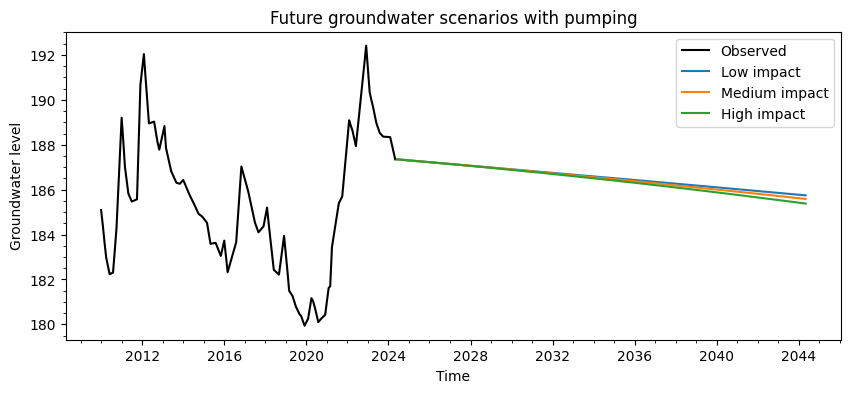

In [205]:
plt.figure(figsize=(10, 4))

# Focus on the most recent 15 years for better resolution of future data
recent_observed = model_data.loc["2010":]

plt.plot(recent_observed.index, recent_observed["groundwater"], 'k-', label="Observed")
plt.plot(scenario_low.index, gw_low, label="Low impact")
plt.plot(scenario_med.index, gw_med, label="Medium impact")
plt.plot(scenario_high.index, gw_high, label="High impact")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Future groundwater scenarios without pumping")
plt.legend()
plt.minorticks_on()
plt.show()

In [206]:
gw_low_pump = run_groundwater_model_pumping(scenario_low, best_recharge, best_sy, pumping_rate=2)
gw_med_pump = run_groundwater_model_pumping(scenario_med, best_recharge, best_sy, pumping_rate=5)
gw_high_pump = run_groundwater_model_pumping(scenario_high, best_recharge, best_sy, pumping_rate=10)

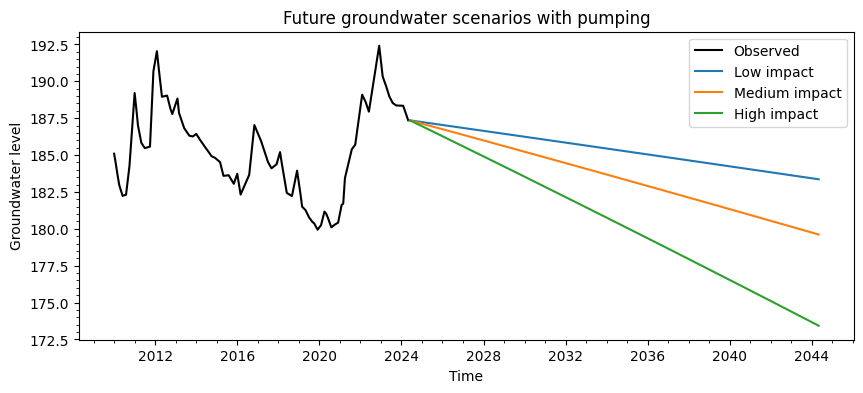

In [207]:
plt.figure(figsize=(10, 4))

# Focus on the most recent 15 years for better resolution of future data
recent_observed = model_data.loc["2010":]

plt.plot(recent_observed.index, recent_observed["groundwater"], 'k-', label="Observed")
plt.plot(scenario_low.index, gw_low_pump, label="Low impact")
plt.plot(scenario_med.index, gw_med_pump, label="Medium impact")
plt.plot(scenario_high.index, gw_high_pump, label="High impact")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Future groundwater scenarios with pumping")
plt.legend()
plt.minorticks_on()
plt.show()

# Reflection

While thinking about potential applications I considered what prior knowledge could help me contextualise a question. I noticed over the course of the group projects that the more difficult ones coincided with an overly complet problem/topic that would have required siginificant prior understanding to better understand would could be done with the data. Hence I reflected on a water science course I did in the summer and considered the concept of water modelling, and more specifically groundwater modelling. Groundwater reserves are of significant important to Australia as out agricultural systems, etc.

**Break down the roles**
Git hub and colab creation: created new repository, created a colab notebook seperately, commited to repository by adding a new branch

**Engagement with content**
- engaged more meaningfully in the course when I started doing hand written notes, helped me fully process the content
- had difficulty fully comprehending/committing to memory techniques and such from the notebook demonstrations - realised this was not the essential part of scientific coding

Identify what worked well, what didn't work so well, what hurdles encountered and how did you pivot

Progress Check (week 11)
- orignally randomly selected a bore site in the Namoi region (that had continuous data from 1970s) however I later found the Lower Namoi hydrogeological conceptual model report which provided context on the geology of the region.
- from this report is selected a new borehole GW030170 because it is described as showing flood and climatic variations...
- note this is not cherry picking, simply gives me the chance to analyse something wiht  

Progress Check (cross correlation)
- realised that it wouldn't be logical to directly compare
- used AI to understand how cross correlation could be coded
- applied to all models and checked with sources online for consistency
- learning opportunity, allowing me to actually play with the data
- had to make new datasets to store this lagged data

Progress Check (regression modelling section)
- conducted single variable regression modelling and realised this could be clouded for this data due to the intervariability of climate
- extended the case to multi-variable (used a bit of AI to check how to do this with bambi) but discovered it's a simple extension just setting more variables (CHECK THIS WASN'T DONE IN CLASS)
- used the extracted coefficients to inform the model